In [1]:
import py_ttcross as ttc
from py_ttcross.quantic_tt_cross.interpolators_1D import (
    greedy_one_dim_func_interpolator,
    ttrc_one_dim_func_interpolator,
)
import numpy as np
import matplotlib.pyplot as plt
from py_ttcross.pdes.operators import OneDimLaplacian, OneDimHeatEqEvolver
from py_ttcross.pdes.als import ALS

In [2]:
def func(x):
    return np.sin(x)


def func2(x):
    B = 2 ** (-30)
    return np.cos(x / B) * np.cos(x / (4 * np.sqrt(5) * B)) * np.exp(-(x**2)) + 2 * np.exp(-x)

In [28]:
interval = [-10, 10]
d = 5

test_interpolator = greedy_one_dim_func_interpolator(
    func=func,
    interval=interval,
    d=d,
    complex_function=False,
    max_bond=5,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

In [29]:
test_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.00015687942504882812 seconds and 1 tries.
Sweep 1
Sweep 2


In [30]:
for tens in test_interpolator.mps:
    print(tens.shape)

(2, 2)
(2, 2, 2)
(2, 2, 2)
(2, 2, 2)
(2, 2)


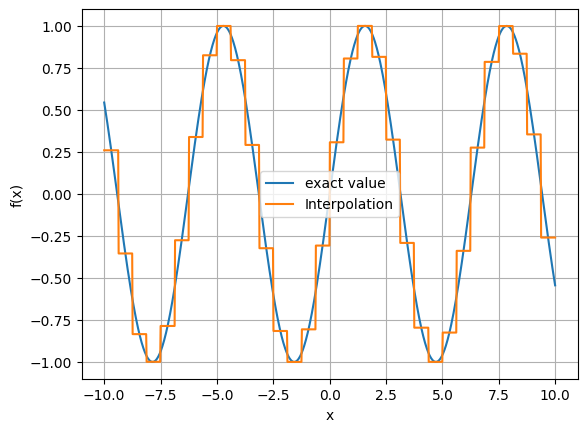

In [31]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([test_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
mps = test_interpolator.interpolation

new_interpolator = greedy_one_dim_func_interpolator.load_mps(mps, interval, complex_func=False)

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/rg/ttf3h2zn7yb9z54k911xl58c0000gn/T/ipykernel_9179/2484605887.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")


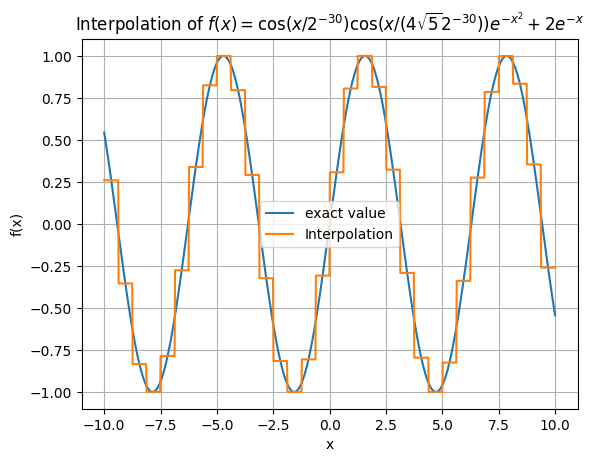

In [33]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([new_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
from py_ttcross.pdes.als import *

In [35]:
prolong_als = ProlongationALS(mps, 10, 12, 1e-10, 40)
prolong_als.optimize()

(array([array([[-0.70685801+0.j,  0.70735547+0.j],
               [ 0.70735547+0.j,  0.70685801+0.j]]),
        array([[[ 3.65480543+0.00e+000j,  0.8237437 +0.00e+000j,
                  0.0768305 +0.00e+000j],
                [ 1.03487987-1.14e-322j, -3.36324675+3.80e-322j,
                 -0.04133711+0.00e+000j]],
 
               [[-0.02766534+3.95e-323j,  1.10429326-1.43e-322j,
                 -0.06057257-4.94e-324j],
                [ 0.94118777+0.00e+000j,  0.53175795-3.46e-323j,
                 -0.25467539+4.94e-324j]]])                     ,
        array([[[-0.74248412+4.0e-323j,  0.18596751+0.0e+000j,
                 -0.00351038+0.0e+000j],
                [ 0.37976878-4.4e-323j, -0.51931352-4.9e-324j,
                  0.01449896+0.0e+000j]],
 
               [[-0.16702629+4.9e-324j, -0.63009389-8.9e-323j,
                 -0.02797431+0.0e+000j],
                [ 0.60533358+4.4e-323j,  0.45543843+7.4e-323j,
                 -0.02117651-4.9e-324j]],
 
               [[ 0

In [36]:
new_interpolator = greedy_one_dim_func_interpolator.load_mps(prolong_als.fine_mps, interval, complex_func=False)

In [37]:
for tens in prolong_als.fine_mps:
    print(tens.shape)

(2, 2)
(2, 2, 3)
(3, 2, 3)
(3, 2, 3)
(3, 2, 2)
(2, 2)


In [38]:
new_interpolator.eval(1)

array(0.90302335+5.e-324j)

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/rg/ttf3h2zn7yb9z54k911xl58c0000gn/T/ipykernel_9179/2484605887.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")


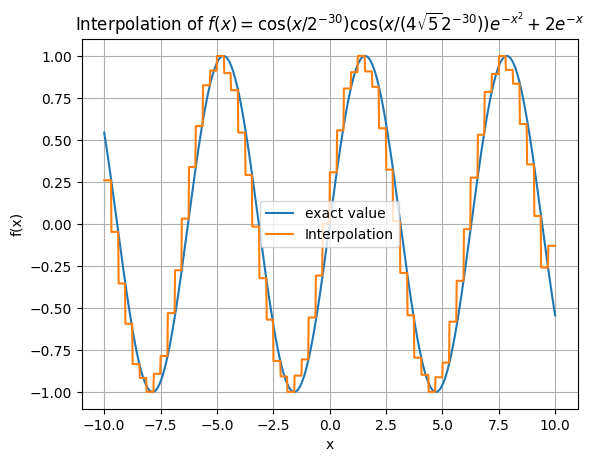

In [39]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([new_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
laplace = OneDimLaplacian(6)

for tens in laplace.laplacian:
    print(tens)

[[[1. 0. 0.]
  [0. 1. 0.]]

 [[0. 0. 1.]
  [1. 0. 0.]]]
[[[[1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 0.]]

  [[0. 1. 0.]
   [0. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 1.]]

  [[0. 0. 0.]
   [0. 0. 0.]]]]
[[[[1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 0.]]

  [[0. 1. 0.]
   [0. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 1.]]

  [[0. 0. 0.]
   [0. 0. 0.]]]]
[[[[1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 0.]]

  [[0. 1. 0.]
   [0. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 1.]]

  [[0. 0. 0.]
   [0. 0. 0.]]]]
[[[[1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 0.]]

  [[0. 1. 0.]
   [0. 0. 0.]]]


 [[[0. 0. 0.]
   [0. 0. 1.]]

  [[0. 0. 0.]
   [0. 0. 0.]]]]
[[[-2.  1.]
  [ 1. -2.]]

 [[ 0.  0.]
  [ 1.  0.]]

 [[ 0.  1.]
  [ 0.  0.]]]


In [41]:
test_als = ALS(prolong_als.fine_mps, laplace.laplacian, 8, 10, 1e-16, 20)

hello


In [42]:
for tns in test_als.opt_mps:
    print(tns.shape)

(2, 2)
(2, 2, 4)
(4, 2, 8)
(8, 2, 4)
(4, 2, 2)
(2, 2)


In [43]:
opt_mps, overlap, truncation_error = test_als.optimize()

In [44]:
new_interpolator = greedy_one_dim_func_interpolator.load_mps(opt_mps, interval, complex_func=False)

In [45]:
for tens in opt_mps:
    print(tens.shape)
    

(2, 2)
(2, 2, 4)
(4, 2, 5)
(5, 2, 4)
(4, 2, 2)
(2, 2)


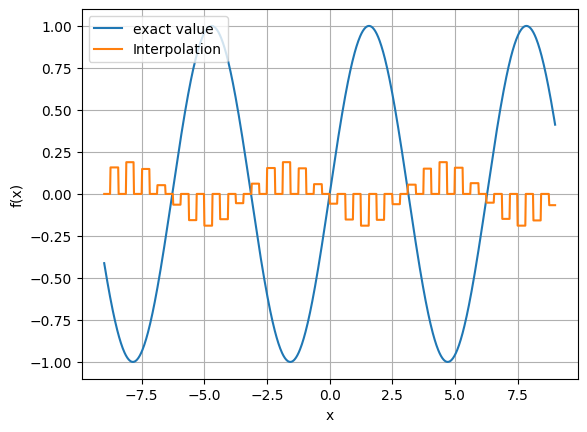

In [46]:
x = np.linspace(interval[0] + 1, interval[1] - 1, 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([new_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()